### LEO-vetter Practice

In [1]:
import numpy as np
import lightkurve as lk
import pandas as pd

from astroquery.mast import Catalogs

from leo_vetter.stellar import quadratic_ldc
from leo_vetter.main import TCELightCurve
from leo_vetter.plots import plot_modshift, plot_summary
from leo_vetter.thresholds import check_thresholds

### M-dwarf Target Selection from ```nearby_TOI_MDs.csv```

In [2]:
def mdwarf_targets_for_leo_vetter(csv_file, n_targets=5):
    """
    Select up to 5 M-dwarf planet targets from nearby_TOI_MDs.csv
    and return the columns needed for LEO-Vetter.

    Returned columns:
    - star_TIC_ID
    - orbital_period_days
    - first_transit_tess_bjd
    - transit_duration_days

    Parameters
    ----------
    csv_file : str
        Path to the CSV file.
    n_targets : int, optional
        Number of targets to return. Default is 5.

    Returns
    -------
    pandas.DataFrame
        Table containing the selected targets.
    """

    if n_targets < 1:
        n_targets = 1
    if n_targets > 5:
        n_targets = 5

    df = pd.read_csv('/Users/madelinejmg/Desktop/PHYS39002/research2026/Catalog/nearby_TOI_MDs.csv')

    required_columns = [
        "TIC ID",
        "Orbital Period (days) Value",
        "Orbital Epoch Value",
        "Transit Duration (hours) Value",
        "Effective Temperature Value",
        "TOI Disposition"
    ]

    missing_columns = [col for col in required_columns if col not in df.columns]
    if len(missing_columns) > 0:
        raise ValueError(
            "Missing required columns: " + ", ".join(missing_columns)
        )

    # Drop rows with missing values in required columns
    df = df.dropna(subset=required_columns).copy()

    # Keep only M-dwarf host stars
    #df = df[df["Effective Temperature Value"] < 4000].copy()

    # Keep only planet candidates
    df = df[df["TOI Disposition"].isin(["PC"])].copy()

    # Keep only rows with positive orbital period and transit duration
    df = df[
        (df["Orbital Period (days) Value"] > 0) &
        (df["Transit Duration (hours) Value"] > 0)
    ].copy()

    # Convert transit duration from hours to days
    df["transit_duration_days"] = df["Transit Duration (hours) Value"] / 24.0

    result = df.head(n_targets)[[
        "TIC ID",
        "Orbital Period (days) Value",
        "Orbital Epoch Value",
        "transit_duration_days"
    ]].copy()

    # Rename columns for consistency
    result = result.rename(columns={
        "TIC ID": "star_TIC_ID",
        "Orbital Period (days) Value": "orbital_period_days",
        "Orbital Epoch Value": "first_transit_tess_bjd"
    })

    return result.reset_index(drop=True)

if __name__ == "__main__":
    csv_file = "nearby_TOI_MDs.csv"

    targets = mdwarf_targets_for_leo_vetter(csv_file, n_targets=5)

    print("\nSelected M-dwarf targets for LEO-Vetter:\n")
    print(targets.to_string(index=False))


Selected M-dwarf targets for LEO-Vetter:

 star_TIC_ID  orbital_period_days  first_transit_tess_bjd  transit_duration_days
   410153553             0.462931             1325.724661               0.026292
   206609630             0.335272             1325.490344               0.029958
   299798795             4.178266             1327.705053               0.069829
   394357918             4.901994             1326.789691               0.055183
    12421862            10.215017             1356.367200               0.082013


### ```TIC-410153553``` Vetting

In [8]:
tic1 = 410153553 
per1 = 0.462931 
epo1 = 1325.724661
dur1 = 0.026292

# NOTE: 1_Basic_Flux_Vetting.ipynb
# Download all SPOC FFI light curves
# astropy
search_result1 = lk.search_lightcurve(f"TIC {tic1}", mission="TESS", author="TESS-SPOC", exptime=1800) # seconds
lcs1 = search_result1.download_all()

# Stitch light curves together into a multi-sector light curve
lc1 = lcs1.stitch()

# Remove NaNs and poor quality cadences
lc1 = lc1[~np.isnan(lc1["flux"]) & (lc1["quality"] == 0)]

# Flatten the light curve
# Highly recommend that the transits are masked out when flattening the light curve
transit_mask1 = lc1.create_transit_mask(transit_time=epo1, period=per1, duration=dur1)
lc_flat1 = lc1.flatten(mask=transit_mask1)

# Extract the relevant arrays
time1 = np.asarray(lc_flat1["time"].value)
raw1 = np.asarray(lc1["flux"].value)
flux1 = np.asarray(lc_flat1["flux"].value)
flux_err1 = np.asarray(lc_flat1["flux_err"].value)

In [9]:
search_result1

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,TESS-SPOC,1800,410153553,0.0


In [4]:
import matplotlib.pyplot as plt

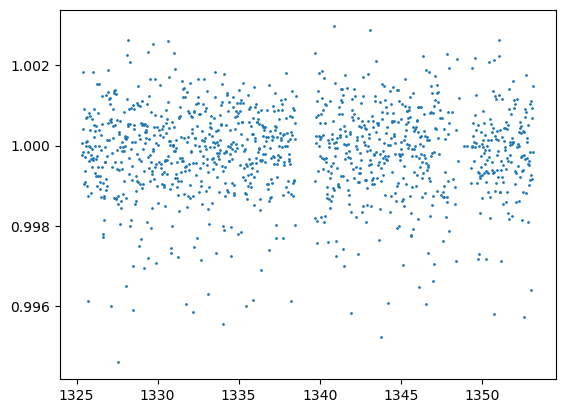

In [10]:
plt.scatter(time1, flux1, s=1)

#### Basic Stellar Properties

In [11]:
result1 = Catalogs.query_criteria(catalog="TIC", ID=tic1)
star1 = {}
star1["tic"] = tic1
for key in ["rad","mass","rho","Teff","logg"]:
    star1[key] = float(result1[key])
    star1["e_"+key] = float(result1["e_"+key])

# Get limb-darkening parameters from Teff and logg
star1["u1"], star1["u2"] = quadratic_ldc(star1["Teff"], star1["logg"])

star1

{'tic': 410153553,
 'rad': 0.188624,
 'e_rad': 0.00571031,
 'mass': 0.157909,
 'e_mass': 0.0200668,
 'rho': 23.5297,
 'e_rho': 0.863072,
 'Teff': 3004.0,
 'e_Teff': 157.0,
 'logg': 5.08528,
 'e_logg': 0.0291861,
 'u1': array(0.1606),
 'u2': array(0.4974)}

In [12]:
tlc1 = TCELightCurve(tic1, time1, raw1, flux1, flux_err1, per1, epo1, dur1, planetno=1)

In [13]:
tlc1.compute_flux_metrics(star1, verbose=True)

# Save results to a file. The default filename is "(tic).(planetno).metrics", but you
# can give this function any desired filename as an input. 
tlc1.save_metrics()

Estimating SES and MES time series...


/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...


/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/individual.py:106: RuntimeWarning: divide by zero encountered in scalar divide
  tlc.redchi2[i] = chi2 / (np.sum(fit_epoch) - 6)


Running modshift...
Estimating derived parameters...
Done!


In [15]:
FA1 = check_thresholds(tlc1.metrics, "FA", verbose=True) # FA is True if any tests failed; False otherwise
FP1 = check_thresholds(tlc1.metrics, "FP", verbose=True) # FP is True if any tests failed; False otherwise

if not FA1 and not FP1:
    print(f"TIC-{tlc1.tic}.{tlc1.planetno} is a planet candidate!")

FA: unphysical transit orbit
Passed all FP tests


### Summary Page for ```TIC1 = 410153553```

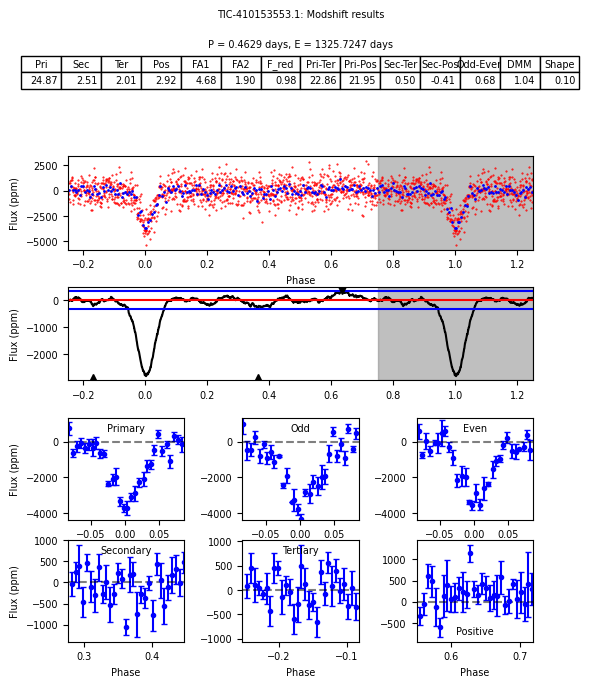

In [16]:
plot_modshift(tlc1, save_fig=False)

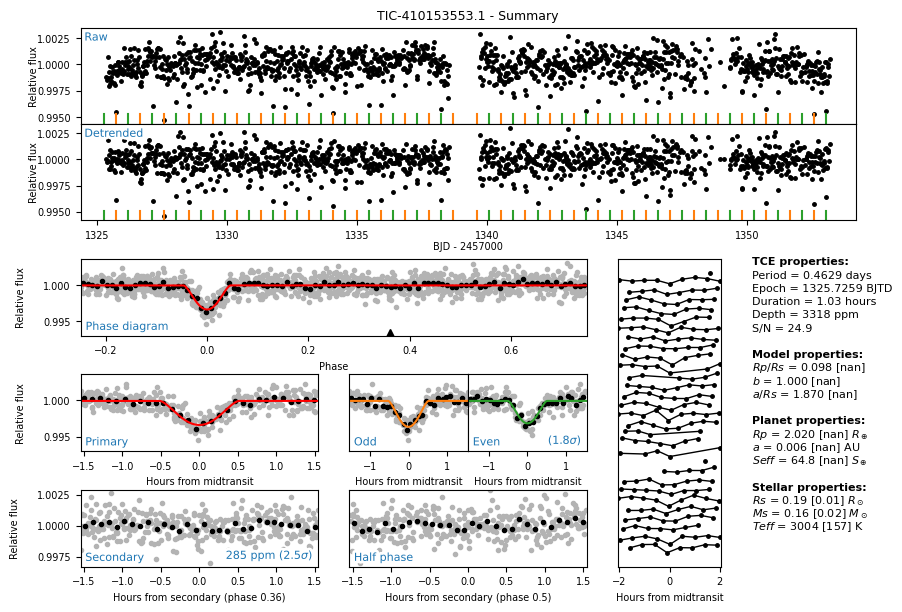

In [17]:
plot_summary(tlc1, star1, save_fig=False)

### ```TIC-299798795``` Vetting

In [19]:
tic2 = 299798795
per2 = 4.178266
epo2 = 1327.705053
dur2 = 0.069829

search_result2 = lk.search_lightcurve(f"TIC {tic2}", mission="TESS", author="TESS-SPOC", exptime=1800)
lcs2 = search_result2.download_all()

lc2 = lcs2.stitch()

lc2 = lc2[~np.isnan(lc2["flux"]) & (lc2["quality"] == 0)]

transit_mask2 = lc2.create_transit_mask(transit_time=epo2, period=per2, duration=dur2)
lc_flat2 = lc2.flatten(mask=transit_mask2)

time2 = np.asarray(lc_flat2["time"].value)
raw2 = np.asarray(lc2["flux"].value)
flux2 = np.asarray(lc_flat2["flux"].value)
flux_err2 = np.asarray(lc_flat2["flux_err"].value)

In [20]:
result2 = Catalogs.query_criteria(catalog="TIC", ID=tic2)
star2 = {}
star2["tic"] = tic2
for key in ["rad","mass","rho","Teff","logg"]:
    star2[key] = float(result2[key])
    star2["e_"+key] = float(result2["e_"+key])

star2["u1"], star2["u2"] = quadratic_ldc(star2["Teff"], star2["logg"])

star2

{'tic': 299798795,
 'rad': 0.404403,
 'e_rad': 0.0120014,
 'mass': 0.396442,
 'e_mass': 0.020234,
 'rho': 5.99427,
 'e_rho': 0.227681,
 'Teff': 3392.0,
 'e_Teff': 157.0,
 'logg': 4.82262,
 'e_logg': 0.00359931,
 'u1': array(0.1555),
 'u2': array(0.4459)}

In [21]:
tlc2 = TCELightCurve(tic2, time2, raw2, flux2, flux_err2, per2, epo2, dur2, planetno=1)

In [22]:
tlc2.compute_flux_metrics(star2, verbose=True)
tlc2.save_metrics()

Estimating SES and MES time series...


/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


In [23]:
FA2 = check_thresholds(tlc2.metrics, "FA", verbose=True) 
FP2 = check_thresholds(tlc2.metrics, "FP", verbose=True)

if not FA2 and not FP2:
    print(f"TIC-{tlc2.tic}.{tlc2.planetno} is a planet candidate!")

FA: signal too weak
FA: not enough valid transits
FA: bad transit shape
FA: events not unique in phased light curve
FA: bad transit model fit
FA: inconsistent transit SNRs
Passed all FP tests


### Summary Page for ```TIC2 = 2997987954```

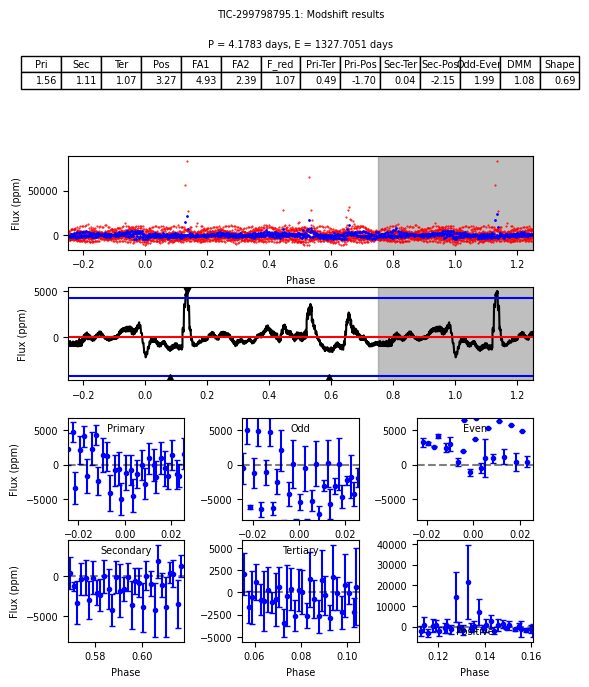

In [24]:
plot_modshift(tlc2, save_fig=False)

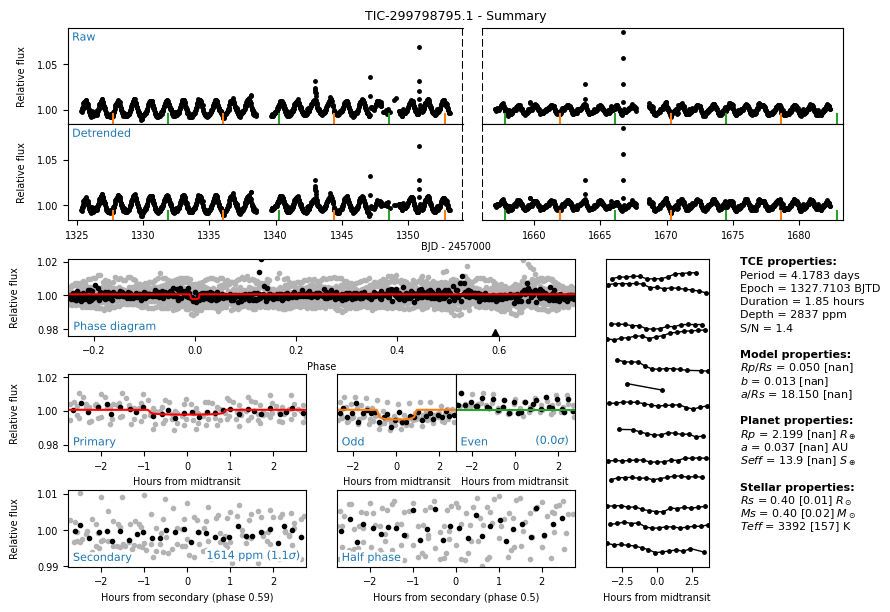

In [25]:
plot_summary(tlc2, star2, save_fig=False)

### ```TIC-394357918``` Vetting

In [26]:
tic3 = 394357918
per3 = 4.901994
epo3 = 1326.789691
dur3 = 0.055183

search_result3 = lk.search_lightcurve(f"TIC {tic3}", mission="TESS", author="TESS-SPOC", exptime=1800)
lcs3 = search_result3.download_all()

lc3 = lcs3.stitch()

lc3 = lc3[~np.isnan(lc3["flux"]) & (lc3["quality"] == 0)]

transit_mask3 = lc3.create_transit_mask(transit_time=epo3, period=per3, duration=dur3)
lc_flat3 = lc3.flatten(mask=transit_mask3)

time3 = np.asarray(lc_flat3["time"].value)
raw3 = np.asarray(lc3["flux"].value)
flux3 = np.asarray(lc_flat3["flux"].value)
flux_err3 = np.asarray(lc_flat3["flux_err"].value)

In [27]:
result3 = Catalogs.query_criteria(catalog="TIC", ID=tic3)
star3 = {}
star3["tic"] = tic3
for key in ["rad","mass","rho","Teff","logg"]:
    star3[key] = float(result3[key])
    star3["e_"+key] = float(result3["e_"+key])

star3["u1"], star3["u2"] = quadratic_ldc(star3["Teff"], star3["logg"])

star3

{'tic': 394357918,
 'rad': 0.240807,
 'e_rad': 0.00741195,
 'mass': 0.210978,
 'e_mass': 0.0201844,
 'rho': 15.1088,
 'e_rho': 0.0541602,
 'Teff': 3239.0,
 'e_Teff': 157.0,
 'logg': 4.99897,
 'e_logg': 0.0149334,
 'u1': array(0.1533),
 'u2': array(0.4776)}

In [28]:
tlc3 = TCELightCurve(tic3, time3, raw3, flux3, flux_err3, per3, epo3, dur3, planetno=1)

In [29]:
tlc3.compute_flux_metrics(star3, verbose=True)
tlc3.save_metrics()

Estimating SES and MES time series...


/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


In [30]:
FA3 = check_thresholds(tlc3.metrics, "FA", verbose=True) 
FP3 = check_thresholds(tlc3.metrics, "FP", verbose=True) 

if not FA3 and not FP3:
    print(f"TIC-{tlc3.tic}.{tlc3.planetno} is a planet candidate!")

Passed all FA tests
Passed all FP tests
TIC-394357918.1 is a planet candidate!


### Summary Page for ```TIC3 = 394357918```

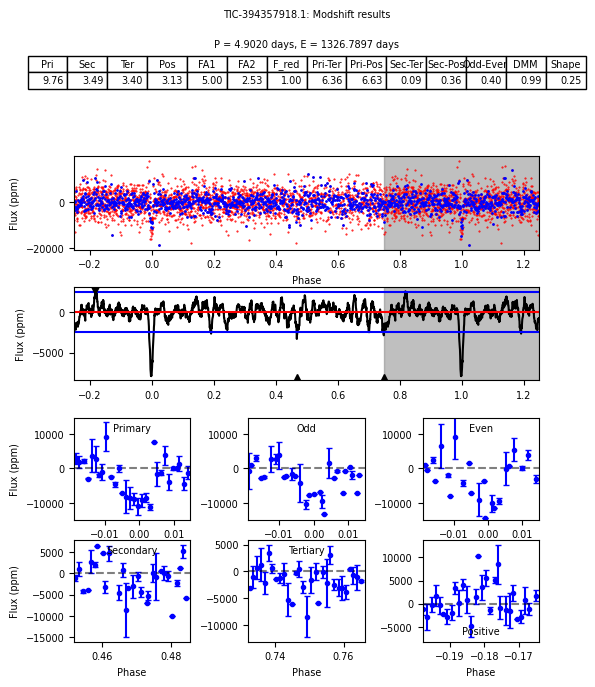

In [31]:
plot_modshift(tlc3, save_fig=False)

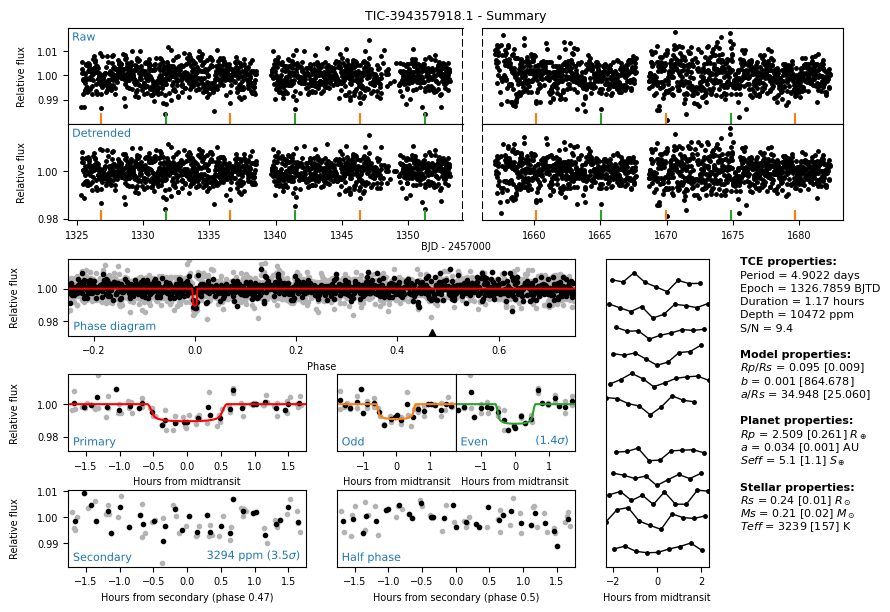

In [32]:
plot_summary(tlc3, star3, save_fig=False)

### ```TIC-12421862``` Vetting

In [33]:
tic4 = 12421862
per4 = 10.215017
epo4 = 1356.367200 
dur4 = 0.082013

search_result4 = lk.search_lightcurve(f"TIC {tic4}", mission="TESS", author="TESS-SPOC", exptime=1800)
lcs4 = search_result4.download_all()

lc4 = lcs4.stitch()

lc4 = lc4[~np.isnan(lc4["flux"]) & (lc4["quality"] == 0)]

transit_mask4 = lc4.create_transit_mask(transit_time=epo4, period=per4, duration=dur4)
lc_flat4 = lc4.flatten(mask=transit_mask4)

time4 = np.asarray(lc_flat4["time"].value)
raw4 = np.asarray(lc4["flux"].value)
flux4 = np.asarray(lc_flat4["flux"].value)
flux_err4 = np.asarray(lc_flat4["flux_err"].value)

In [34]:
result4 = Catalogs.query_criteria(catalog="TIC", ID=tic4)
star4 = {}
star4["tic"] = tic4
for key in ["rad","mass","rho","Teff","logg"]:
    star4[key] = float(result4[key])
    star4["e_"+key] = float(result4["e_"+key])

star4["u1"], star4["u2"] = quadratic_ldc(star4["Teff"], star4["logg"])

star4

{'tic': 12421862,
 'rad': 0.447336,
 'e_rad': 0.0133167,
 'mass': 0.4437,
 'e_mass': 0.0202915,
 'rho': 4.95665,
 'e_rho': 0.216084,
 'Teff': 3782.0,
 'e_Teff': 157.0,
 'logg': 4.78389,
 'e_logg': 0.00598935,
 'u1': array(0.2263),
 'u2': array(0.3985)}

In [35]:
tlc4 = TCELightCurve(tic4, time4, raw4, flux4, flux_err4, per4, epo4, dur4, planetno=1)

In [36]:
tlc4.compute_flux_metrics(star4, verbose=True)
tlc4.save_metrics()

Estimating SES and MES time series...


/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


In [37]:
FA4 = check_thresholds(tlc4.metrics, "FA", verbose=True) 
FP4 = check_thresholds(tlc4.metrics, "FP", verbose=True)

if not FA4 and not FP4:
    print(f"TIC-{tlc4.tic}.{tlc4.planetno} is a planet candidate!")

FA: events not unique in local light curve
FA: bad transit model fit
Passed all FP tests


### Summary Page for ```TIC4 = 12421862```

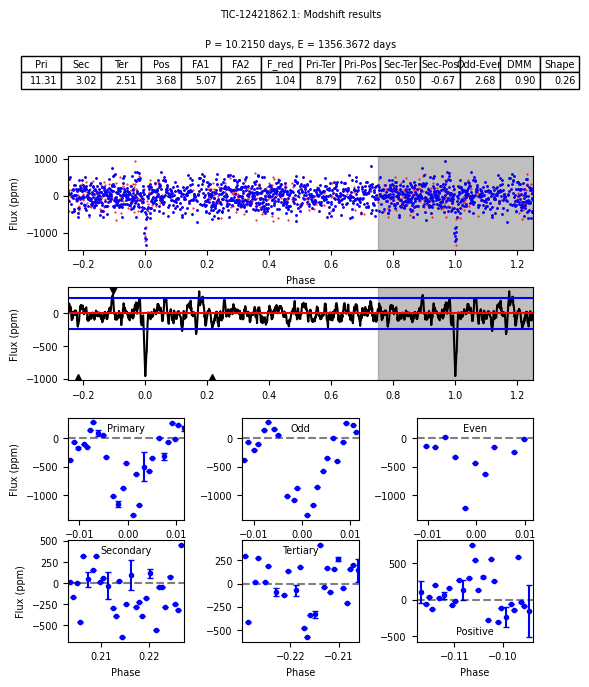

In [38]:
plot_modshift(tlc4, save_fig=False)

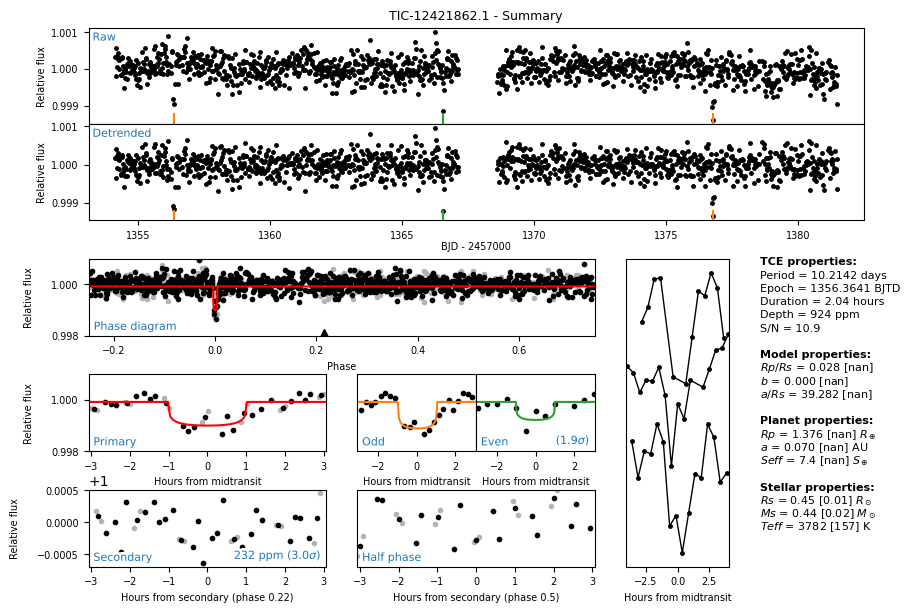

In [39]:
plot_summary(tlc4, star4, save_fig=False)

### ```TIC-234523599``` Vetting

In [40]:
tic5 = 234523599
per5 = 3.795518
epo5 = 1325.650603
dur5 = 0.084159

search_result5 = lk.search_lightcurve(f"TIC {tic5}", mission="TESS", author="TESS-SPOC", exptime=1800)
lcs5 = search_result5.download_all()

lc5 = lcs5.stitch()

lc5 = lc5[~np.isnan(lc5["flux"]) & (lc5["quality"] == 0)]

transit_mask5 = lc5.create_transit_mask(transit_time=epo5, period=per5, duration=dur5)
lc_flat5 = lc5.flatten(mask=transit_mask5)

time5 = np.asarray(lc_flat5["time"].value)
raw5 = np.asarray(lc5["flux"].value)
flux5 = np.asarray(lc_flat5["flux"].value)
flux_err5 = np.asarray(lc_flat5["flux_err"].value)

In [41]:
result5 = Catalogs.query_criteria(catalog="TIC", ID=tic5)
star5 = {}
star5["tic"] = tic5
for key in ["rad","mass","rho","Teff","logg"]:
    star5[key] = float(result5[key])
    star5["e_"+key] = float(result5["e_"+key])

star5["u1"], star5["u2"] = quadratic_ldc(star5["Teff"], star5["logg"])

star5

{'tic': 234523599,
 'rad': 0.445372,
 'e_rad': 0.01356,
 'mass': 0.44159,
 'e_mass': 0.0205201,
 'rho': 4.99862,
 'e_rho': 0.22441,
 'Teff': 3402.0,
 'e_Teff': 157.0,
 'logg': 4.78564,
 'e_logg': 0.006258,
 'u1': array(0.1555),
 'u2': array(0.4459)}

In [42]:
tlc5 = TCELightCurve(tic5, time5, raw5, flux5, flux_err5, per5, epo5, dur5, planetno=1)

In [43]:
tlc5.compute_flux_metrics(star5, verbose=True)
tlc5.save_metrics()

Estimating SES and MES time series...


/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


In [44]:
FA5 = check_thresholds(tlc5.metrics, "FA", verbose=True) 
FP5 = check_thresholds(tlc5.metrics, "FP", verbose=True)

if not FA5 and not FP5:
    print(f"TIC-{tlc5.tic}.{tlc5.planetno} is a planet candidate!")

Passed all FA tests
Passed all FP tests
TIC-234523599.1 is a planet candidate!


### Summary Page for ```TIC5 = 234523599```

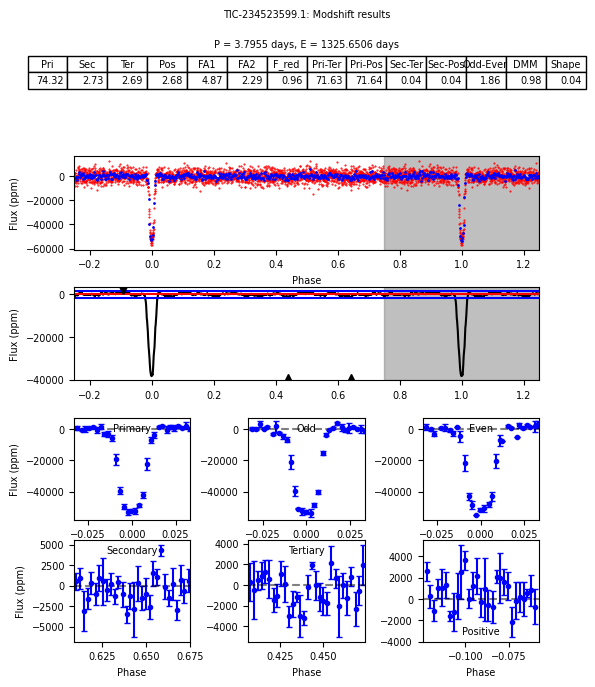

In [45]:
plot_modshift(tlc5, save_fig=False)

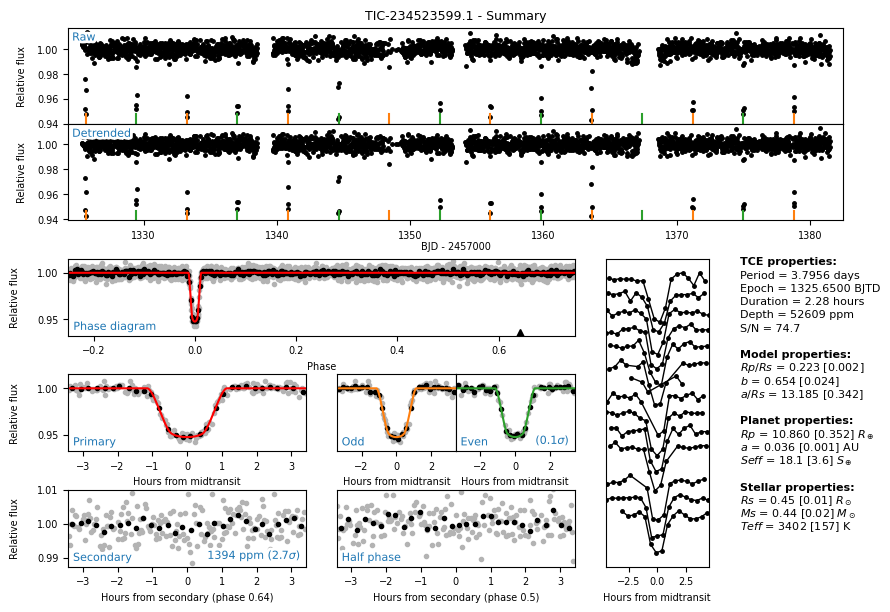

In [46]:
plot_summary(tlc5, star5, save_fig=False)